# Optuna 하이퍼파라미터 최적화 - Importance 안정화

## 개선 사항
1. **Random Seed 완전 고정**: 모든 랜덤 요소에 시드 적용
2. **충분한 Trial 수**: 최소 100 trials 이상 사용
3. **여러 번 실행 후 평균**: 5번 반복하여 안정적인 importance 계산

In [33]:
# 필요한 라이브러리 설치
!pip install optuna catboost koreanize-matplotlib -q

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
import warnings
import time
import random
from collections import defaultdict
warnings.filterwarnings('ignore')

# Optuna
import optuna
from optuna import Trial
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_slice,
    plot_contour
)

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, f1_score

# Optuna 로깅 레벨 조정
optuna.logging.set_verbosity(optuna.logging.WARNING)

Optuna 버전: 4.7.0
NumPy 버전: 2.0.2
Pandas 버전: 2.2.2


In [34]:
# Random Seed 완전 고정 함수

def set_all_seeds(seed=42):
    """
    모든 랜덤 시드를 고정하는 함수
    - Python random
    - NumPy
    - 환경 변수 (재현성 확보)
    """
    random.seed(seed)
    np.random.seed(seed)

    # 환경 변수 설정 (일부 라이브러리에서 사용)
    import os
    os.environ['PYTHONHASHSEED'] = str(seed)

    print(f"모든 랜덤 시드를 {seed}로 고정")

# 기본 시드 설정
BASE_SEED = 42
set_all_seeds(BASE_SEED)

모든 랜덤 시드를 42로 고정


In [20]:
# 데이터 로드 및 전처리
print("Loading Pima Indians Diabetes Dataset...")
pima = fetch_openml(name='diabetes', version=1, as_frame=True)
X = pima.data
y = pima.target.map({'tested_negative': 0, 'tested_positive': 1}).astype(int)

print(f"데이터 크기: {X.shape}")
print(f"피처 목록: {list(X.columns)}")
print(f"\n클래스 분포:\n{y.value_counts()}")
print(f"\n클래스 비율:\n{y.value_counts(normalize=True).round(3)}")

Loading Pima Indians Diabetes Dataset...
데이터 크기: (768, 8)
피처 목록: ['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age']

클래스 분포:
class
0    500
1    268
Name: count, dtype: int64

클래스 비율:
class
0    0.651
1    0.349
Name: proportion, dtype: float64


In [21]:
# 데이터 분할 (stratify로 클래스 비율 유지, random_state 고정)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=BASE_SEED,  # Seed 고정
    stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"\nTrain 클래스 분포:\n{y_train.value_counts()}")
print(f"Test 클래스 분포:\n{y_test.value_counts()}")

Train: (614, 8), Test: (154, 8)

Train 클래스 분포:
class
0    400
1    214
Name: count, dtype: int64
Test 클래스 분포:
class
0    100
1     54
Name: count, dtype: int64


## XGBoost - 안정적인 Importance 계산

In [22]:
# ===============================================================================
# 충분한 Trial 수 (100 trials)
# 여러 번 실행 후 평균 (5회 반복)
# ===============================================================================

def objective_xgboost(trial, random_state):
    """
    XGBoost 목적 함수
    - random_state를 파라미터로 받아서 매번 다른 시드 사용
    """
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 0.5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 1),
        'random_state': random_state,  # ✅ Seed 고정
        'eval_metric': 'logloss',
        'use_label_encoder': False
    }

    model = XGBClassifier(**params)
    cv_score = cross_val_score(
        model, X_train, y_train,
        cv=5, scoring='accuracy', n_jobs=-1
    ).mean()

    return cv_score


# ===============================================================================
# XGBoost: 5번 반복 실행하여 importance 평균 계산
# ===============================================================================

N_RUNS = 5  # 반복 횟수
N_TRIALS = 100  # 충분한 Trial 수

print("\n" + "="*80)
print(f"XGBoost Optuna 최적화 - {N_RUNS}회 반복, 각 {N_TRIALS} trials")
print("="*80)

xgb_studies = []
xgb_importances = []

for run in range(N_RUNS):
    print(f"\n▶ Run {run+1}/{N_RUNS}")

    # 각 run마다 다른 시드 사용 (재현성 유지)
    run_seed = BASE_SEED + run
    set_all_seeds(run_seed)

    # Optuna Study 생성 (sampler에 seed 고정)
    study = optuna.create_study(
        direction='maximize',
        study_name=f'xgboost_run_{run+1}',
        sampler=optuna.samplers.TPESampler(seed=run_seed)  # ✅ Sampler seed 고정
    )

    # 최적화 실행
    study.optimize(
        lambda trial: objective_xgboost(trial, run_seed),
        n_trials=N_TRIALS,
        show_progress_bar=True
    )

    # Study 저장
    xgb_studies.append(study)

    # Importance 계산 및 저장
    importance = optuna.importance.get_param_importances(study)
    xgb_importances.append(importance)

    print(f" 최고 CV 점수: {study.best_value:.4f}")
    print(f" Top 3 중요 파라미터: {list(importance.keys())[:3]}")

print("\nXGBoost 최적화 완료!")


XGBoost Optuna 최적화 - 5회 반복, 각 100 trials

▶ Run 1/5
✅ 모든 랜덤 시드를 42로 고정했습니다.


  0%|          | 0/100 [00:00<?, ?it/s]

  ✓ 최고 CV 점수: 0.7867
  ✓ Top 3 중요 파라미터: ['min_child_weight', 'learning_rate', 'subsample']

▶ Run 2/5
✅ 모든 랜덤 시드를 43로 고정했습니다.


  0%|          | 0/100 [00:00<?, ?it/s]

  ✓ 최고 CV 점수: 0.7867
  ✓ Top 3 중요 파라미터: ['learning_rate', 'reg_lambda', 'min_child_weight']

▶ Run 3/5
✅ 모든 랜덤 시드를 44로 고정했습니다.


...

  ✓ 최고 CV 점수: 0.7883
  ✓ Top 3 중요 파라미터: ['learning_rate', 'colsample_bytree', 'n_estimators']

▶ Run 4/5
✅ 모든 랜덤 시드를 45로 고정했습니다.


  0%|          | 0/100 [00:00<?, ?it/s]

  ✓ 최고 CV 점수: 0.7850
  ✓ Top 3 중요 파라미터: ['learning_rate', 'min_child_weight', 'max_depth']

▶ Run 5/5
✅ 모든 랜덤 시드를 46로 고정했습니다.


  0%|          | 0/100 [00:00<?, ?it/s]

  ✓ 최고 CV 점수: 0.7834
  ✓ Top 3 중요 파라미터: ['learning_rate', 'reg_alpha', 'min_child_weight']

✅ XGBoost 최적화 완료!


In [23]:
# ===============================================================================
# XGBoost: Importance 평균 계산 및 표준편차 분석
# ===============================================================================

# 모든 파라미터 목록 추출
all_params = set()
for imp in xgb_importances:
    all_params.update(imp.keys())

# 각 파라미터별 importance 값들을 모음
importance_by_param = defaultdict(list)

for imp in xgb_importances:
    for param in all_params:
        importance_by_param[param].append(imp.get(param, 0.0))

# 평균과 표준편차 계산
xgb_avg_importance = {}
xgb_std_importance = {}

for param, values in importance_by_param.items():
    xgb_avg_importance[param] = np.mean(values)
    xgb_std_importance[param] = np.std(values)

# 평균 importance로 정렬
sorted_params = sorted(xgb_avg_importance.items(), key=lambda x: x[1], reverse=True)

print("\n" + "="*80)
print("XGBoost - 파라미터 Importance 평균 및 표준편차")
print("="*80)
print(f"{'파라미터':<20} {'평균 Importance':>18} {'표준편차':>15} {'변동계수(CV)':>15}")
print("-" * 80)

for param, avg_imp in sorted_params:
    std_imp = xgb_std_importance[param]
    cv = (std_imp / avg_imp * 100) if avg_imp > 0 else 0  # 변동계수 (Coefficient of Variation)
    print(f"{param:<20} {avg_imp:>18.6f} {std_imp:>15.6f} {cv:>14.2f}%")

print("\n 변동계수(CV)가 낮을수록 안정적인 파라미터")


XGBoost - 파라미터 Importance 평균 및 표준편차
파라미터                      평균 Importance            표준편차        변동계수(CV)
--------------------------------------------------------------------------------
learning_rate                  0.482677        0.182250          37.76%
min_child_weight               0.150378        0.112166          74.59%
reg_lambda                     0.074576        0.084128         112.81%
n_estimators                   0.062855        0.030357          48.30%
subsample                      0.062017        0.042804          69.02%
reg_alpha                      0.053920        0.045347          84.10%
colsample_bytree               0.050289        0.036538          72.66%
max_depth                      0.042047        0.036402          86.57%
gamma                          0.021241        0.005458          25.70%

💡 변동계수(CV)가 낮을수록 안정적인 파라미터입니다.


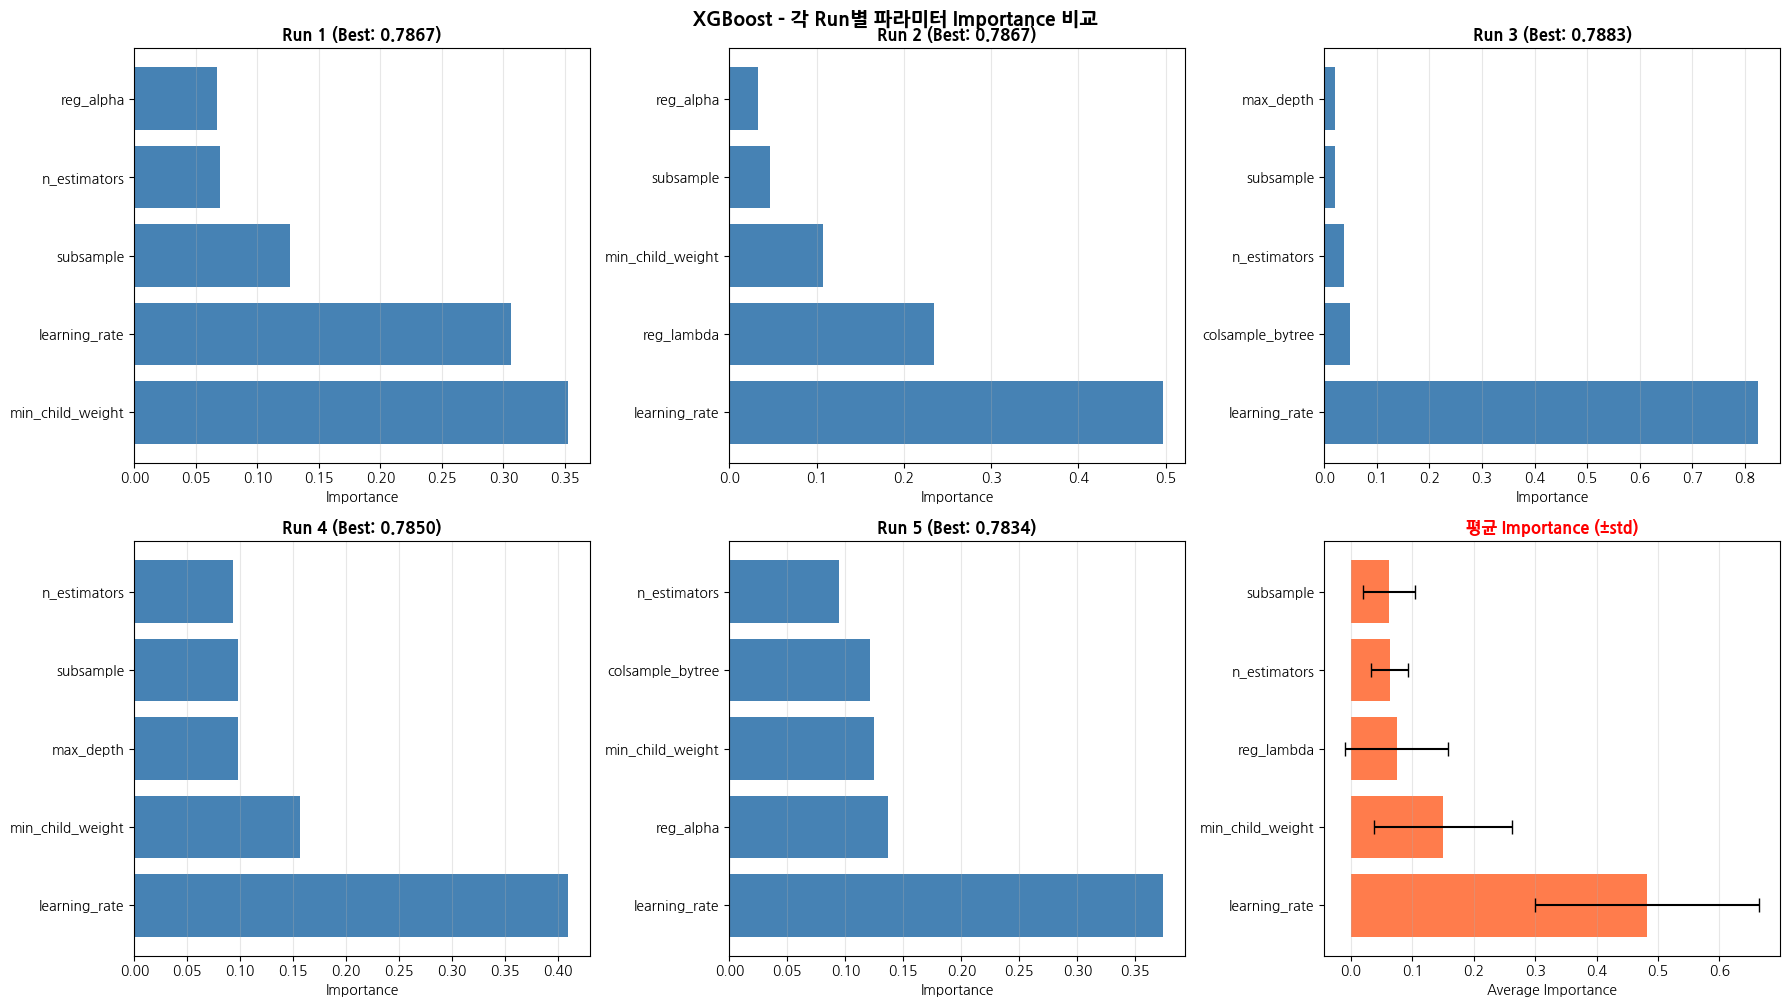


📊 위 그래프는 5번의 실행에서 각각 계산된 importance를 보여줍니다.
   마지막 그래프는 평균값과 표준편차를 보여줍니다.


In [24]:
# ===============================================================================
# XGBoost: 각 Run별 Importance 시각화
# ===============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# 각 run별 importance 플롯
for i, (study, importance) in enumerate(zip(xgb_studies, xgb_importances)):
    ax = axes[i]

    # Top 5 파라미터만 표시
    top_params = sorted(importance.items(), key=lambda x: x[1], reverse=True)[:5]
    params = [p[0] for p in top_params]
    values = [p[1] for p in top_params]

    ax.barh(params, values, color='steelblue')
    ax.set_xlabel('Importance')
    ax.set_title(f'Run {i+1} (Best: {study.best_value:.4f})', fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

# 평균 importance 플롯
ax = axes[5]
top_avg = sorted(xgb_avg_importance.items(), key=lambda x: x[1], reverse=True)[:5]
params = [p[0] for p in top_avg]
values = [p[1] for p in top_avg]
stds = [xgb_std_importance[p] for p in params]

ax.barh(params, values, xerr=stds, color='orangered', alpha=0.7, capsize=5)
ax.set_xlabel('Average Importance')
ax.set_title(f'평균 Importance (±std)', fontweight='bold', color='red')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.suptitle('XGBoost - 각 Run별 파라미터 Importance 비교',
             fontsize=14, fontweight='bold', y=1.002)
plt.show()

## LightGBM - 안정적인 Importance 계산

In [25]:
def objective_lgbm(trial, random_state):
    """
    LightGBM 목적 함수
    """
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 1),
        'random_state': random_state,  # Seed 고정
        'verbose': -1
    }

    model = LGBMClassifier(**params)
    cv_score = cross_val_score(
        model, X_train, y_train,
        cv=5, scoring='accuracy', n_jobs=-1
    ).mean()

    return cv_score


# ===============================================================================
# LightGBM: 5번 반복 실행
# ===============================================================================

print("\n" + "="*80)
print(f"LightGBM Optuna 최적화 - {N_RUNS}회 반복, 각 {N_TRIALS} trials")
print("="*80)

lgbm_studies = []
lgbm_importances = []

for run in range(N_RUNS):
    print(f"\n▶ Run {run+1}/{N_RUNS}")

    run_seed = BASE_SEED + run
    set_all_seeds(run_seed)

    study = optuna.create_study(
        direction='maximize',
        study_name=f'lgbm_run_{run+1}',
        sampler=optuna.samplers.TPESampler(seed=run_seed)
    )

    study.optimize(
        lambda trial: objective_lgbm(trial, run_seed),
        n_trials=N_TRIALS,
        show_progress_bar=True
    )

    lgbm_studies.append(study)
    importance = optuna.importance.get_param_importances(study)
    lgbm_importances.append(importance)

    print(f" 최고 CV 점수: {study.best_value:.4f}")
    print(f" Top 3 중요 파라미터: {list(importance.keys())[:3]}")

print("\n LightGBM 최적화 완료!")


LightGBM Optuna 최적화 - 5회 반복, 각 100 trials

▶ Run 1/5
✅ 모든 랜덤 시드를 42로 고정했습니다.


  0%|          | 0/100 [00:00<?, ?it/s]

  ✓ 최고 CV 점수: 0.7850
  ✓ Top 3 중요 파라미터: ['learning_rate', 'n_estimators', 'max_depth']

▶ Run 2/5
✅ 모든 랜덤 시드를 43로 고정했습니다.


  0%|          | 0/100 [00:00<?, ?it/s]

  ✓ 최고 CV 점수: 0.7883
  ✓ Top 3 중요 파라미터: ['learning_rate', 'min_child_samples', 'num_leaves']

▶ Run 3/5
✅ 모든 랜덤 시드를 44로 고정했습니다.


...

  ✓ 최고 CV 점수: 0.7818
  ✓ Top 3 중요 파라미터: ['learning_rate', 'reg_lambda', 'n_estimators']

▶ Run 4/5
✅ 모든 랜덤 시드를 45로 고정했습니다.


  0%|          | 0/100 [00:00<?, ?it/s]

  ✓ 최고 CV 점수: 0.7834
  ✓ Top 3 중요 파라미터: ['learning_rate', 'colsample_bytree', 'min_child_samples']

▶ Run 5/5
✅ 모든 랜덤 시드를 46로 고정했습니다.


  0%|          | 0/100 [00:00<?, ?it/s]

  ✓ 최고 CV 점수: 0.7834
  ✓ Top 3 중요 파라미터: ['learning_rate', 'min_child_samples', 'reg_alpha']

✅ LightGBM 최적화 완료!


In [26]:
# ===============================================================================
# LightGBM: Importance 평균 계산
# ===============================================================================

all_params = set()
for imp in lgbm_importances:
    all_params.update(imp.keys())

importance_by_param = defaultdict(list)
for imp in lgbm_importances:
    for param in all_params:
        importance_by_param[param].append(imp.get(param, 0.0))

lgbm_avg_importance = {}
lgbm_std_importance = {}

for param, values in importance_by_param.items():
    lgbm_avg_importance[param] = np.mean(values)
    lgbm_std_importance[param] = np.std(values)

sorted_params = sorted(lgbm_avg_importance.items(), key=lambda x: x[1], reverse=True)

print("\n" + "="*80)
print("LightGBM - 파라미터 Importance 평균 및 표준편차")
print("="*80)
print(f"{'파라미터':<20} {'평균 Importance':>18} {'표준편차':>15} {'변동계수(CV)':>15}")
print("-" * 80)

for param, avg_imp in sorted_params:
    std_imp = lgbm_std_importance[param]
    cv = (std_imp / avg_imp * 100) if avg_imp > 0 else 0
    print(f"{param:<20} {avg_imp:>18.6f} {std_imp:>15.6f} {cv:>14.2f}%")


LightGBM - 파라미터 Importance 평균 및 표준편차
파라미터                      평균 Importance            표준편차        변동계수(CV)
--------------------------------------------------------------------------------
learning_rate                  0.614073        0.066531          10.83%
n_estimators                   0.073607        0.040697          55.29%
min_child_samples              0.060465        0.035917          59.40%
max_depth                      0.054606        0.027706          50.74%
colsample_bytree               0.046566        0.050015         107.41%
reg_lambda                     0.041713        0.034292          82.21%
reg_alpha                      0.040513        0.024861          61.36%
subsample                      0.036536        0.015675          42.90%
num_leaves                     0.031921        0.029261          91.67%


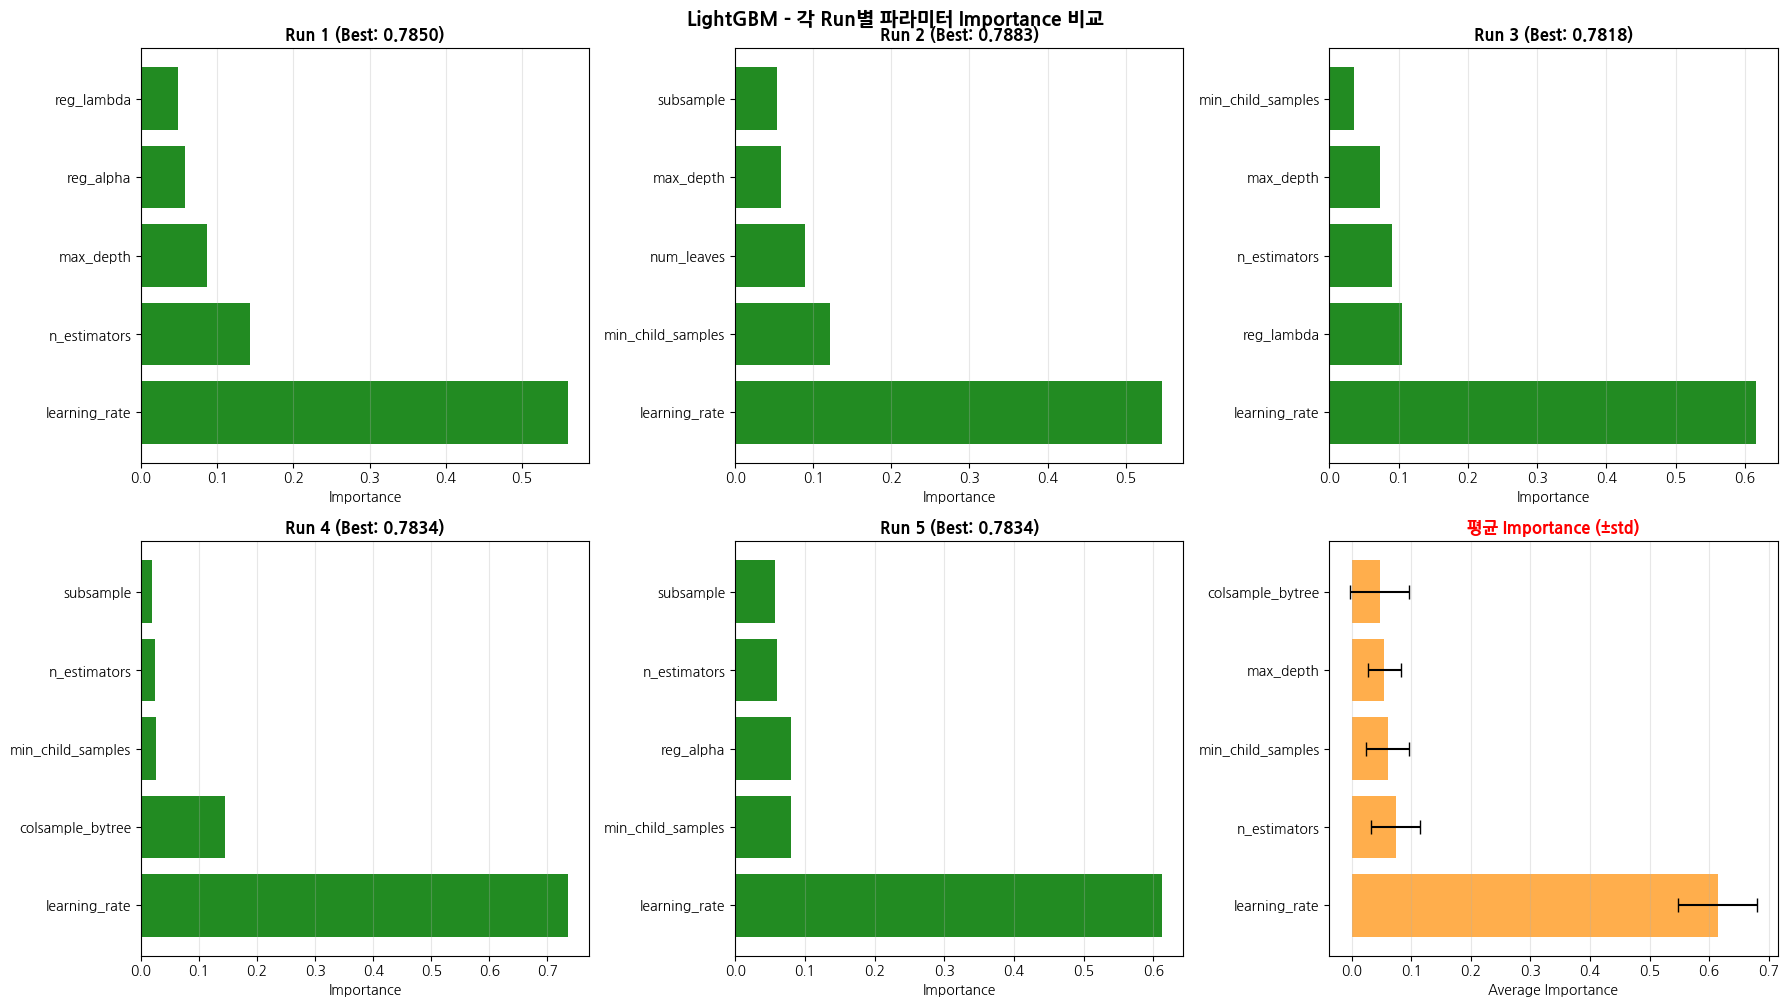

In [27]:
# ===============================================================================
# LightGBM: 시각화
# ===============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (study, importance) in enumerate(zip(lgbm_studies, lgbm_importances)):
    ax = axes[i]
    top_params = sorted(importance.items(), key=lambda x: x[1], reverse=True)[:5]
    params = [p[0] for p in top_params]
    values = [p[1] for p in top_params]

    ax.barh(params, values, color='forestgreen')
    ax.set_xlabel('Importance')
    ax.set_title(f'Run {i+1} (Best: {study.best_value:.4f})', fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

ax = axes[5]
top_avg = sorted(lgbm_avg_importance.items(), key=lambda x: x[1], reverse=True)[:5]
params = [p[0] for p in top_avg]
values = [p[1] for p in top_avg]
stds = [lgbm_std_importance[p] for p in params]

ax.barh(params, values, xerr=stds, color='darkorange', alpha=0.7, capsize=5)
ax.set_xlabel('Average Importance')
ax.set_title(f'평균 Importance (±std)', fontweight='bold', color='red')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.suptitle('LightGBM - 각 Run별 파라미터 Importance 비교',
             fontsize=14, fontweight='bold', y=1.002)
plt.show()

## CatBoost - 안정적인 Importance 계산

In [28]:
def objective_catboost(trial, random_state):
    """
    CatBoost 목적 함수
    """
    params = {
        'iterations': trial.suggest_int('iterations', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 3, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'random_strength': trial.suggest_float('random_strength', 0, 10),
        'random_state': random_state,  # Seed 고정
        'verbose': 0
    }

    model = CatBoostClassifier(**params)
    cv_score = cross_val_score(
        model, X_train, y_train,
        cv=5, scoring='accuracy', n_jobs=-1
    ).mean()

    return cv_score


# ===============================================================================
# CatBoost: 5번 반복 실행
# ===============================================================================

print("\n" + "="*80)
print(f"CatBoost Optuna 최적화 - {N_RUNS}회 반복, 각 {N_TRIALS} trials")
print("="*80)

cat_studies = []
cat_importances = []

for run in range(N_RUNS):
    print(f"\n▶ Run {run+1}/{N_RUNS}")

    run_seed = BASE_SEED + run
    set_all_seeds(run_seed)

    study = optuna.create_study(
        direction='maximize',
        study_name=f'catboost_run_{run+1}',
        sampler=optuna.samplers.TPESampler(seed=run_seed)
    )

    study.optimize(
        lambda trial: objective_catboost(trial, run_seed),
        n_trials=N_TRIALS,
        show_progress_bar=True
    )

    cat_studies.append(study)
    importance = optuna.importance.get_param_importances(study)
    cat_importances.append(importance)

    print(f" 최고 CV 점수: {study.best_value:.4f}")
    print(f" Top 3 중요 파라미터: {list(importance.keys())[:3]}")

print("\n CatBoost 최적화 완료!")


CatBoost Optuna 최적화 - 5회 반복, 각 100 trials

▶ Run 1/5
✅ 모든 랜덤 시드를 42로 고정했습니다.


  0%|          | 0/100 [00:00<?, ?it/s]

  ✓ 최고 CV 점수: 0.7883
  ✓ Top 3 중요 파라미터: ['iterations', 'learning_rate', 'depth']

▶ Run 2/5
✅ 모든 랜덤 시드를 43로 고정했습니다.


  0%|          | 0/100 [00:00<?, ?it/s]

  ✓ 최고 CV 점수: 0.7883
  ✓ Top 3 중요 파라미터: ['iterations', 'learning_rate', 'l2_leaf_reg']

▶ Run 3/5
✅ 모든 랜덤 시드를 44로 고정했습니다.


...

  ✓ 최고 CV 점수: 0.7883
  ✓ Top 3 중요 파라미터: ['learning_rate', 'border_count', 'l2_leaf_reg']

▶ Run 4/5
✅ 모든 랜덤 시드를 45로 고정했습니다.


  0%|          | 0/100 [00:00<?, ?it/s]

  ✓ 최고 CV 점수: 0.7916
  ✓ Top 3 중요 파라미터: ['iterations', 'learning_rate', 'l2_leaf_reg']

▶ Run 5/5
✅ 모든 랜덤 시드를 46로 고정했습니다.


  0%|          | 0/100 [00:00<?, ?it/s]

  ✓ 최고 CV 점수: 0.7867
  ✓ Top 3 중요 파라미터: ['learning_rate', 'iterations', 'border_count']

✅ CatBoost 최적화 완료!


In [29]:
# ===============================================================================
# CatBoost: Importance 평균 계산
# ===============================================================================

all_params = set()
for imp in cat_importances:
    all_params.update(imp.keys())

importance_by_param = defaultdict(list)
for imp in cat_importances:
    for param in all_params:
        importance_by_param[param].append(imp.get(param, 0.0))

cat_avg_importance = {}
cat_std_importance = {}

for param, values in importance_by_param.items():
    cat_avg_importance[param] = np.mean(values)
    cat_std_importance[param] = np.std(values)

sorted_params = sorted(cat_avg_importance.items(), key=lambda x: x[1], reverse=True)

print("\n" + "="*80)
print("CatBoost - 파라미터 Importance 평균 및 표준편차")
print("="*80)
print(f"{'파라미터':<20} {'평균 Importance':>18} {'표준편차':>15} {'변동계수(CV)':>15}")
print("-" * 80)

for param, avg_imp in sorted_params:
    std_imp = cat_std_importance[param]
    cv = (std_imp / avg_imp * 100) if avg_imp > 0 else 0
    print(f"{param:<20} {avg_imp:>18.6f} {std_imp:>15.6f} {cv:>14.2f}%")


CatBoost - 파라미터 Importance 평균 및 표준편차
파라미터                      평균 Importance            표준편차        변동계수(CV)
--------------------------------------------------------------------------------
iterations                     0.409709        0.177794          43.40%
learning_rate                  0.250434        0.125160          49.98%
border_count                   0.101450        0.078463          77.34%
l2_leaf_reg                    0.091500        0.048152          52.62%
random_strength                0.053974        0.015495          28.71%
depth                          0.050228        0.026111          51.98%
bagging_temperature            0.042705        0.017206          40.29%


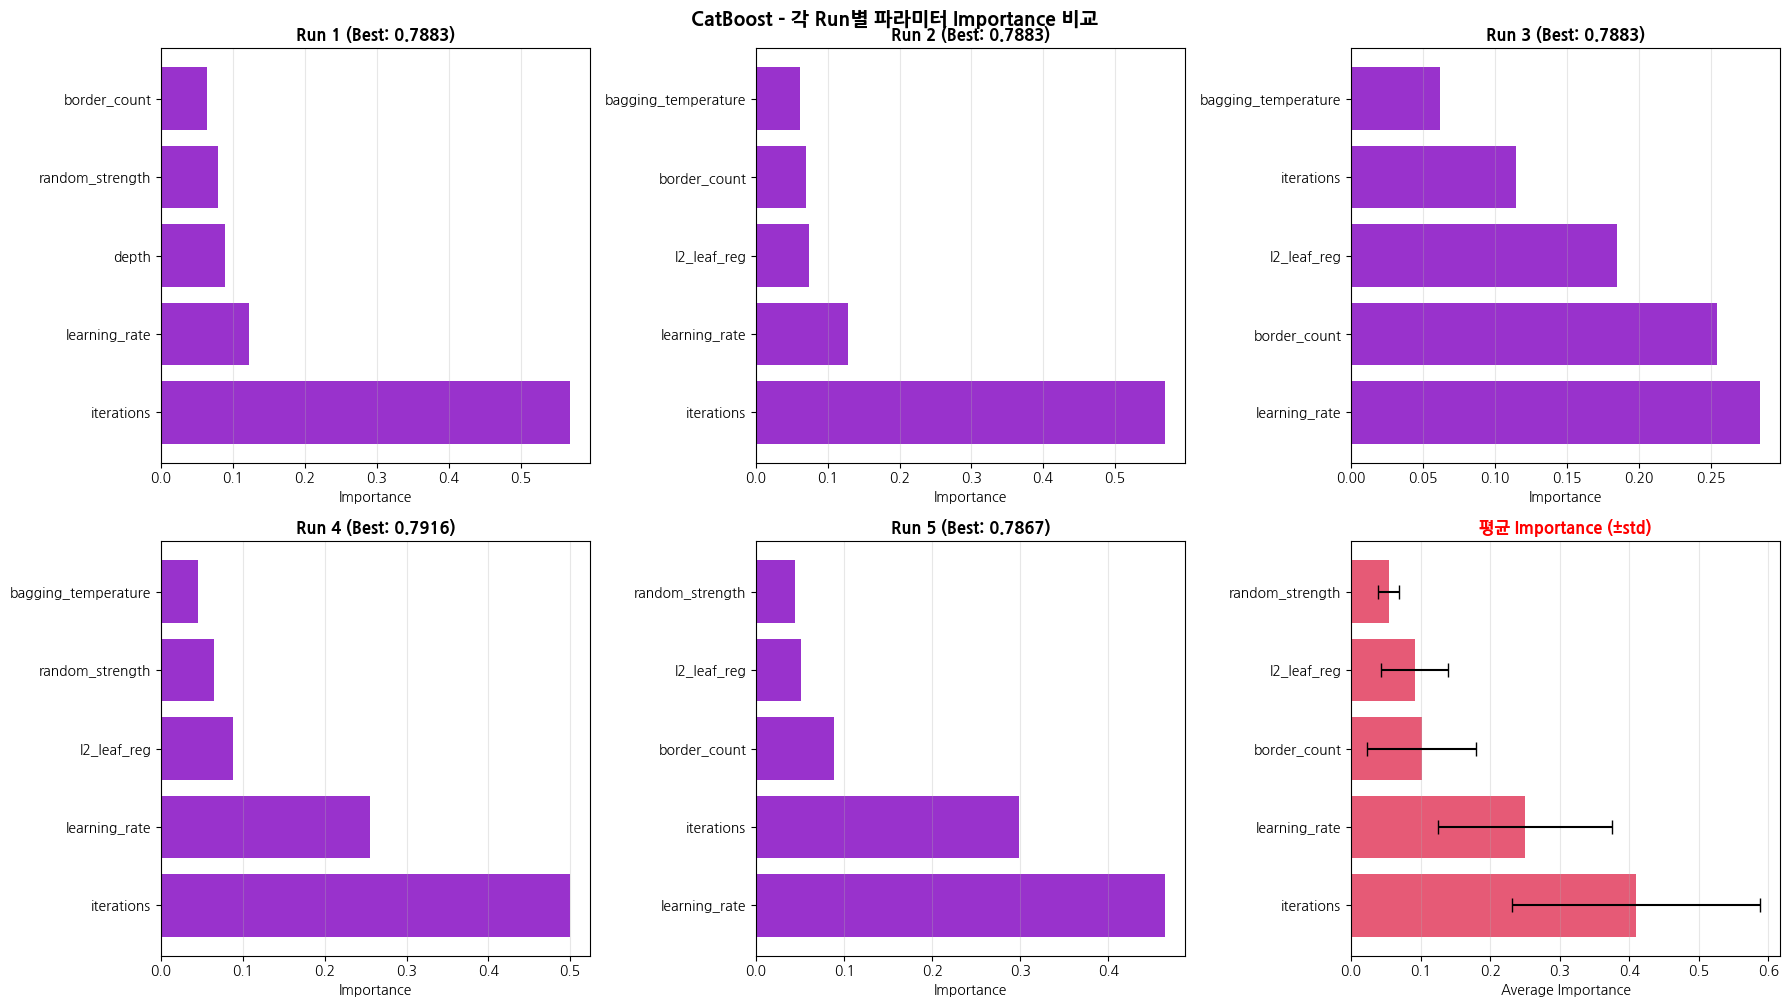

In [30]:
# ===============================================================================
# CatBoost: 시각화
# ===============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (study, importance) in enumerate(zip(cat_studies, cat_importances)):
    ax = axes[i]
    top_params = sorted(importance.items(), key=lambda x: x[1], reverse=True)[:5]
    params = [p[0] for p in top_params]
    values = [p[1] for p in top_params]

    ax.barh(params, values, color='darkorchid')
    ax.set_xlabel('Importance')
    ax.set_title(f'Run {i+1} (Best: {study.best_value:.4f})', fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

ax = axes[5]
top_avg = sorted(cat_avg_importance.items(), key=lambda x: x[1], reverse=True)[:5]
params = [p[0] for p in top_avg]
values = [p[1] for p in top_avg]
stds = [cat_std_importance[p] for p in params]

ax.barh(params, values, xerr=stds, color='crimson', alpha=0.7, capsize=5)
ax.set_xlabel('Average Importance')
ax.set_title(f'평균 Importance (±std)', fontweight='bold', color='red')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.suptitle('CatBoost - 각 Run별 파라미터 Importance 비교',
             fontsize=14, fontweight='bold', y=1.002)
plt.show()

## 전체 모델 비교 및 최종 평가

In [31]:
# ===============================================================================
# 각 모델의 최고 성능 Study로 테스트 세트 평가
# ===============================================================================

print("\n" + "="*80)
print("테스트 세트 최종 평가 (각 모델의 최고 Study 사용)")
print("="*80)

results = []

# XGBoost 최고 study 찾기
best_xgb_idx = np.argmax([s.best_value for s in xgb_studies])
best_xgb_study = xgb_studies[best_xgb_idx]

xgb_model = XGBClassifier(**best_xgb_study.best_params,
                          random_state=BASE_SEED,
                          eval_metric='logloss',
                          use_label_encoder=False)
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

results.append({
    'Model': 'XGBoost',
    'Best Run': best_xgb_idx + 1,
    'CV Score': best_xgb_study.best_value,
    'Test Accuracy': accuracy_score(y_test, y_pred),
    'Test F1': f1_score(y_test, y_pred, average='weighted')
})

print(f"XGBoost (Run {best_xgb_idx+1}): Test Acc={results[-1]['Test Accuracy']:.4f}, F1={results[-1]['Test F1']:.4f}")

# LightGBM 최고 study 찾기
best_lgbm_idx = np.argmax([s.best_value for s in lgbm_studies])
best_lgbm_study = lgbm_studies[best_lgbm_idx]

lgbm_model = LGBMClassifier(**best_lgbm_study.best_params,
                            random_state=BASE_SEED,
                            verbose=-1)
lgbm_model.fit(X_train, y_train)
y_pred = lgbm_model.predict(X_test)

results.append({
    'Model': 'LightGBM',
    'Best Run': best_lgbm_idx + 1,
    'CV Score': best_lgbm_study.best_value,
    'Test Accuracy': accuracy_score(y_test, y_pred),
    'Test F1': f1_score(y_test, y_pred, average='weighted')
})

print(f"LightGBM (Run {best_lgbm_idx+1}): Test Acc={results[-1]['Test Accuracy']:.4f}, F1={results[-1]['Test F1']:.4f}")

# CatBoost 최고 study 찾기
best_cat_idx = np.argmax([s.best_value for s in cat_studies])
best_cat_study = cat_studies[best_cat_idx]

cat_model = CatBoostClassifier(**best_cat_study.best_params,
                               random_state=BASE_SEED,
                               verbose=0)
cat_model.fit(X_train, y_train)
y_pred = cat_model.predict(X_test)

results.append({
    'Model': 'CatBoost',
    'Best Run': best_cat_idx + 1,
    'CV Score': best_cat_study.best_value,
    'Test Accuracy': accuracy_score(y_test, y_pred),
    'Test F1': f1_score(y_test, y_pred, average='weighted')
})

print(f"CatBoost (Run {best_cat_idx+1}): Test Acc={results[-1]['Test Accuracy']:.4f}, F1={results[-1]['Test F1']:.4f}")

results_df = pd.DataFrame(results)
print("\n" + "="*80)
print(results_df.to_string(index=False))


테스트 세트 최종 평가 (각 모델의 최고 Study 사용)
XGBoost (Run 3): Test Acc=0.7662, F1=0.7628
LightGBM (Run 2): Test Acc=0.7597, F1=0.7540
CatBoost (Run 4): Test Acc=0.7403, F1=0.7364

   Model  Best Run  CV Score  Test Accuracy  Test F1
 XGBoost         3  0.788271       0.766234 0.762763
LightGBM         2  0.788325       0.759740 0.753992
CatBoost         4  0.791550       0.740260 0.736403


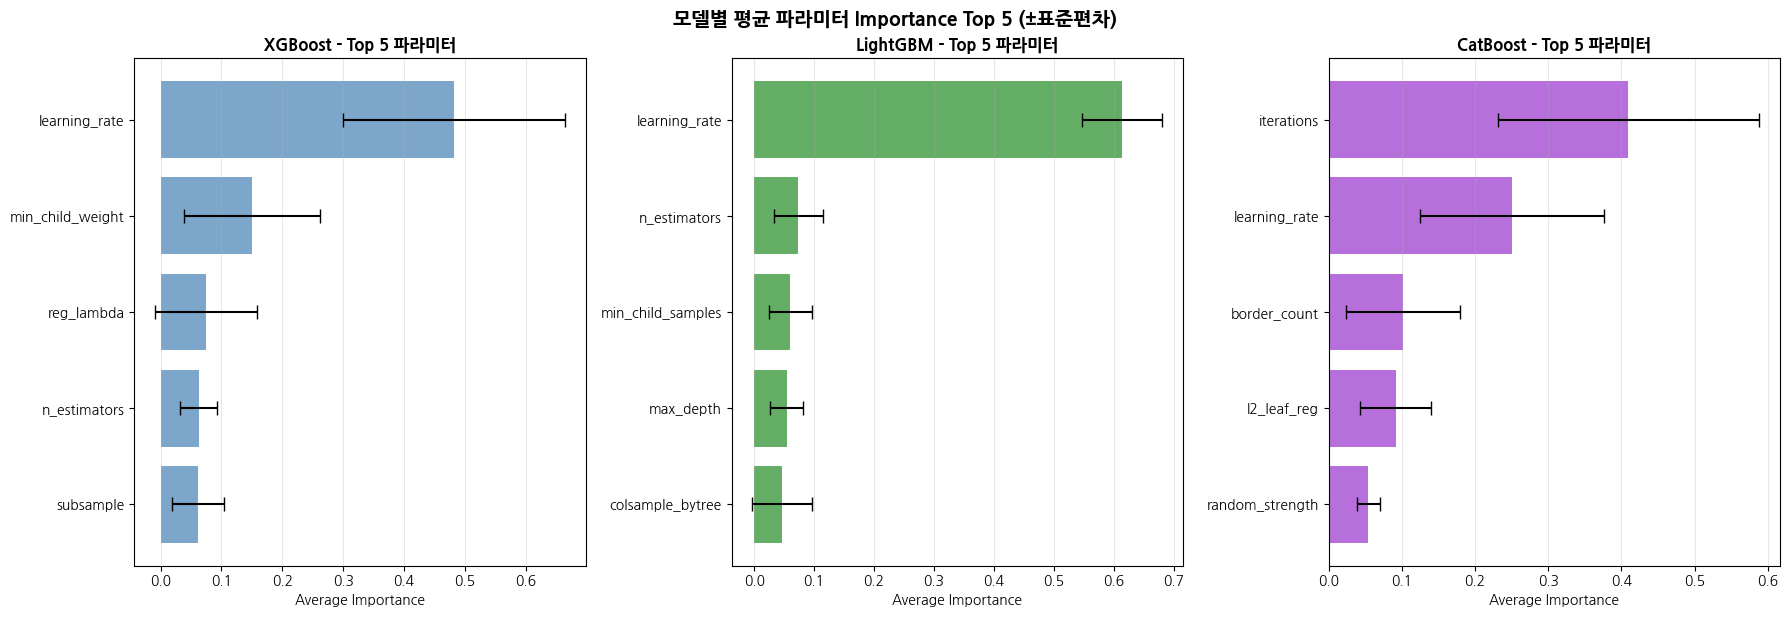

In [32]:
# ===============================================================================
# 전체 모델의 평균 Importance Top 5 비교
# ===============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# XGBoost
ax = axes[0]
top_xgb = sorted(xgb_avg_importance.items(), key=lambda x: x[1], reverse=True)[:5]
params = [p[0] for p in top_xgb]
values = [p[1] for p in top_xgb]
stds = [xgb_std_importance[p] for p in params]

ax.barh(params, values, xerr=stds, color='steelblue', alpha=0.7, capsize=5)
ax.set_xlabel('Average Importance')
ax.set_title('XGBoost - Top 5 파라미터', fontweight='bold', fontsize=12)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

# LightGBM
ax = axes[1]
top_lgbm = sorted(lgbm_avg_importance.items(), key=lambda x: x[1], reverse=True)[:5]
params = [p[0] for p in top_lgbm]
values = [p[1] for p in top_lgbm]
stds = [lgbm_std_importance[p] for p in params]

ax.barh(params, values, xerr=stds, color='forestgreen', alpha=0.7, capsize=5)
ax.set_xlabel('Average Importance')
ax.set_title('LightGBM - Top 5 파라미터', fontweight='bold', fontsize=12)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

# CatBoost
ax = axes[2]
top_cat = sorted(cat_avg_importance.items(), key=lambda x: x[1], reverse=True)[:5]
params = [p[0] for p in top_cat]
values = [p[1] for p in top_cat]
stds = [cat_std_importance[p] for p in params]

ax.barh(params, values, xerr=stds, color='darkorchid', alpha=0.7, capsize=5)
ax.set_xlabel('Average Importance')
ax.set_title('CatBoost - Top 5 파라미터', fontweight='bold', fontsize=12)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

plt.tight_layout()
plt.suptitle('모델별 평균 파라미터 Importance Top 5 (±표준편차)',
             fontsize=14, fontweight='bold', y=1.02)
plt.show()